## Import packages

In [4]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src import fetch_stock_data, add_technical_indicators

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black'
})
sns.set_palette("husl")

## Fetch stock data

In [5]:
ticker = "AAPL"
df = fetch_stock_data(ticker=ticker, period="2y", interval="1d")
print(f"Shape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-03-14,171.439758,172.737941,170.498329,171.350574,72913500
2024-03-15,171.063171,171.063171,168.754183,169.626252,121752700
2024-03-18,172.153259,176.107280,171.955066,173.986581,75604200
2024-03-19,174.491974,175.017193,171.469478,172.767661,55215200
2024-03-20,177.058624,177.058624,173.510909,174.135233,53423100


## Data types and info

In [6]:
print(df.dtypes)
print(f"\nIndex type: {type(df.index)}")
df.info()

Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Index type: <class 'pandas.DatetimeIndex'>
<class 'pandas.DataFrame'>
DatetimeIndex: 501 entries, 2024-03-14 to 2026-03-13
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   501 non-null    float64
 1   High    501 non-null    float64
 2   Low     501 non-null    float64
 3   Open    501 non-null    float64
 4   Volume  501 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.5 KB


## Basic statistics

In [7]:
df.describe()

Price,Close,High,Low,Open,Volume
count,501.000000,501.000000,501.000000,501.000000,5.010000e+02
mean,226.490736,228.748117,224.080069,226.300224,5.460918e+07
std,29.030152,29.141188,28.876804,29.093791,2.722521e+07
min,163.511887,164.899254,162.600186,163.858736,1.791060e+07
25%,208.371826,211.147457,206.122761,208.276197,4.001940e+07
50%,226.035202,228.002278,223.899215,225.935779,4.806810e+07
75%,247.298645,250.630876,244.922072,247.577564,5.935740e+07
max,285.922455,288.350192,283.035157,285.932471,3.186799e+08


## Check for missing values

In [8]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nTotal rows: {len(df)}")

Missing values:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Total rows: 501


## Plot closing price

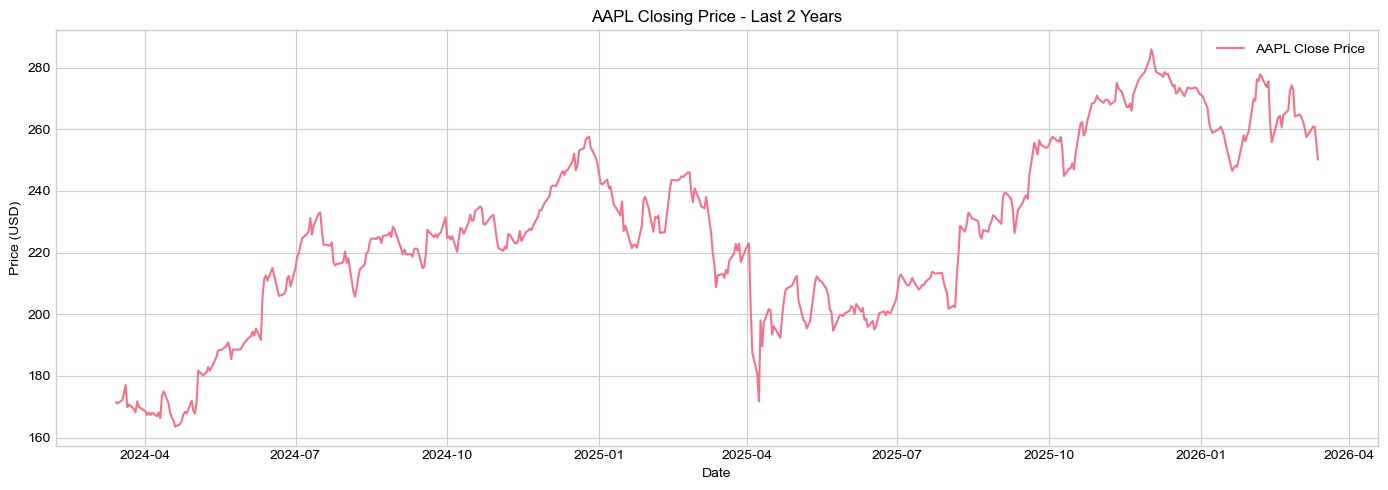

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df['Close'], label=f'{ticker} Close Price', linewidth=1.5)
plt.title(f'{ticker} Closing Price - Last 2 Years')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Plot volume

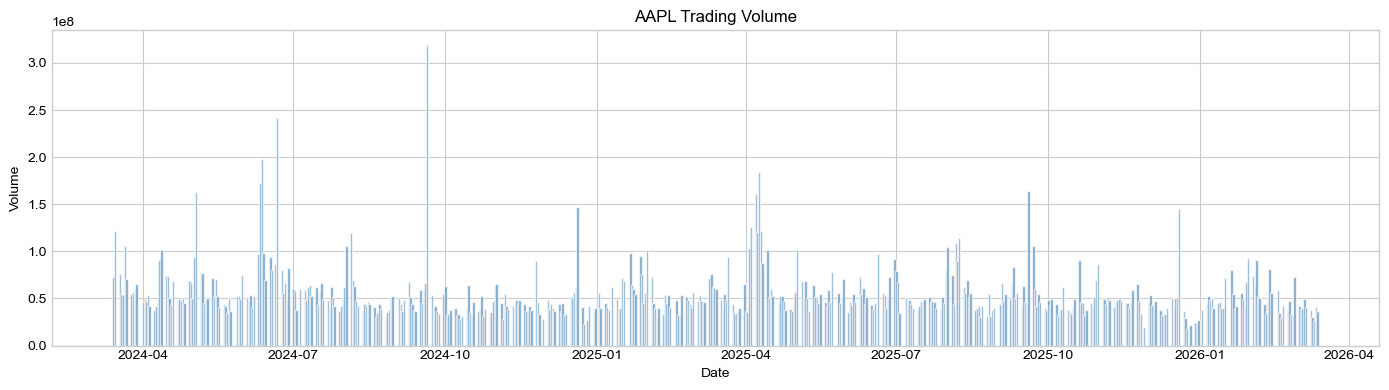

In [10]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['Volume'], color='steelblue', alpha=0.7, width=1.5)
plt.title(f'{ticker} Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

## Plot OHLC together

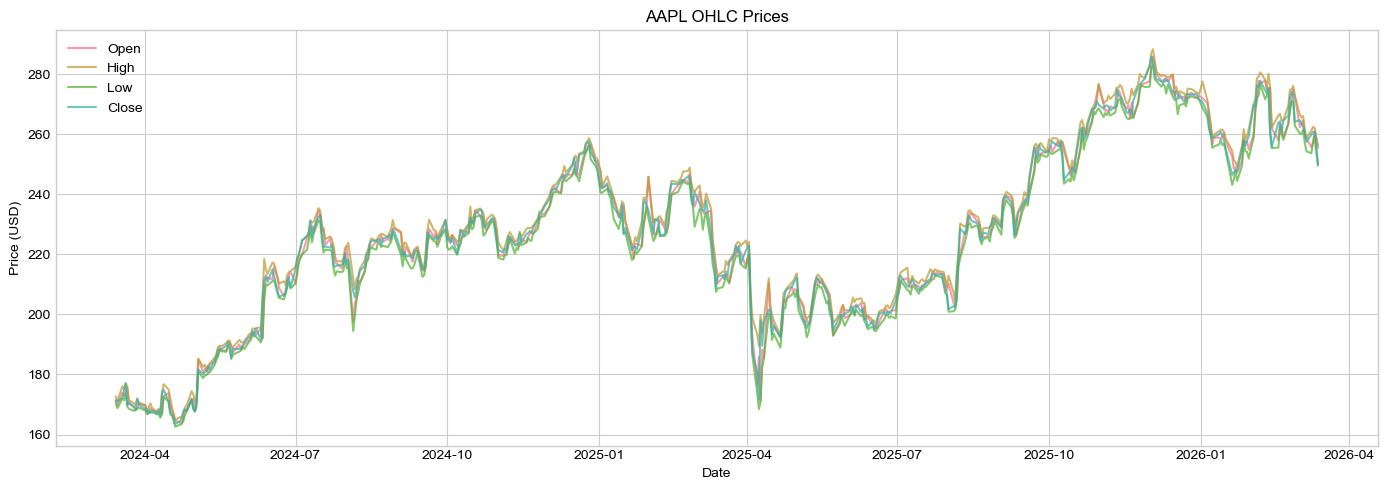

In [11]:

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Open'], label='Open', alpha=0.7)
ax.plot(df['High'], label='High', alpha=0.7)
ax.plot(df['Low'], label='Low', alpha=0.7)
ax.plot(df['Close'], label='Close', alpha=0.7)
ax.set_title(f'{ticker} OHLC Prices')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

## Daily returns distribution

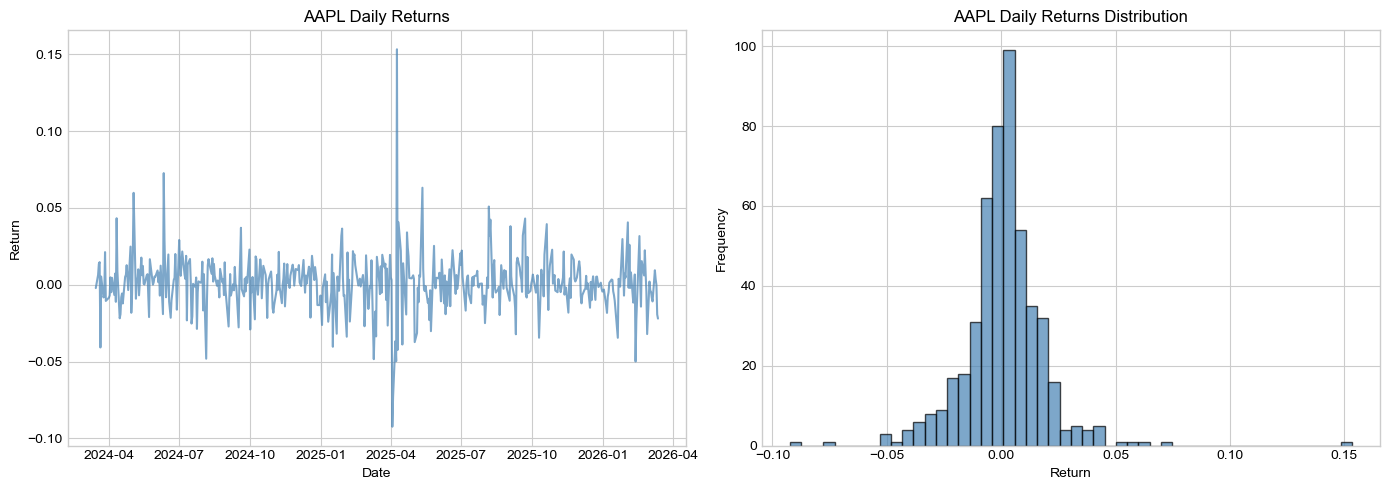

In [12]:

df['Daily_Return'] = df['Close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df['Daily_Return'], color='steelblue', alpha=0.7)
axes[0].set_title(f'{ticker} Daily Returns')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Return')

axes[1].hist(df['Daily_Return'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title(f'{ticker} Daily Returns Distribution')
axes[1].set_xlabel('Return')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Moving averages

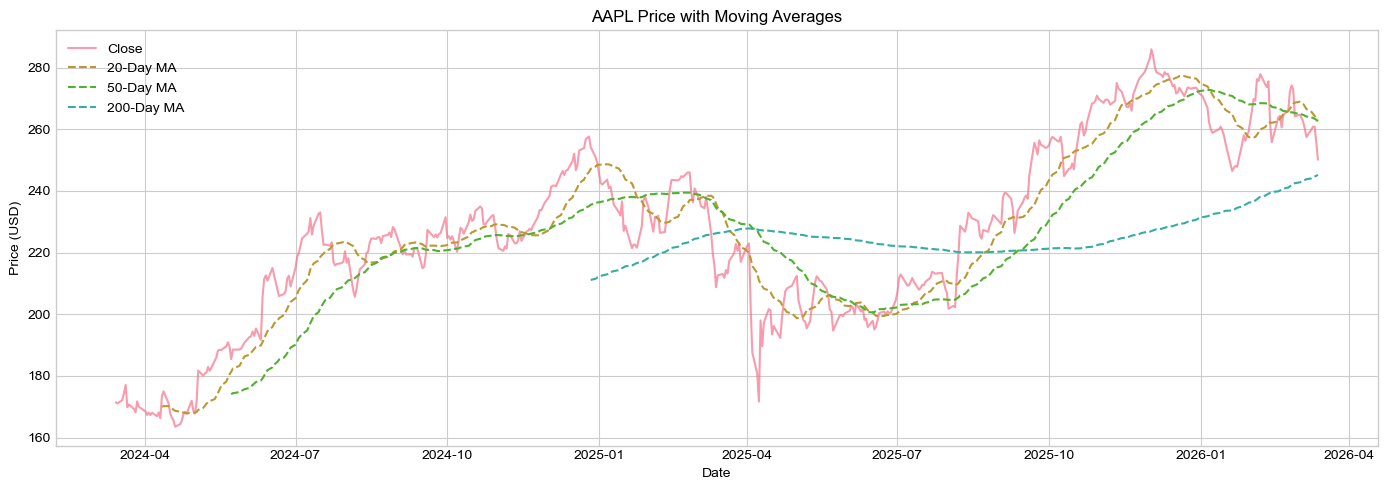

In [13]:

df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['Close'], label='Close', alpha=0.7)
plt.plot(df['MA_20'], label='20-Day MA', linestyle='--')
plt.plot(df['MA_50'], label='50-Day MA', linestyle='--')
plt.plot(df['MA_200'], label='200-Day MA', linestyle='--')
plt.title(f'{ticker} Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Add technical indicators

In [14]:

df_ta = fetch_stock_data(ticker=ticker, period="2y", interval="1d")
df_ta = add_technical_indicators(df_ta)
print(f"Total features after adding indicators: {df_ta.shape[1]}")
df_ta.columns.tolist()

['Close',
 'High',
 'Low',
 'Open',
 'Volume',
 'volume_adi',
 'volume_obv',
 'volume_cmf',
 'volume_fi',
 'volume_em',
 'volume_sma_em',
 'volume_vpt',
 'volume_vwap',
 'volume_mfi',
 'volume_nvi',
 'volatility_bbm',
 'volatility_bbh',
 'volatility_bbl',
 'volatility_bbw',
 'volatility_bbp',
 'volatility_bbhi',
 'volatility_bbli',
 'volatility_kcc',
 'volatility_kch',
 'volatility_kcl',
 'volatility_kcw',
 'volatility_kcp',
 'volatility_kchi',
 'volatility_kcli',
 'volatility_dcl',
 'volatility_dch',
 'volatility_dcm',
 'volatility_dcw',
 'volatility_dcp',
 'volatility_atr',
 'volatility_ui',
 'trend_macd',
 'trend_macd_signal',
 'trend_macd_diff',
 'trend_sma_fast',
 'trend_sma_slow',
 'trend_ema_fast',
 'trend_ema_slow',
 'trend_vortex_ind_pos',
 'trend_vortex_ind_neg',
 'trend_vortex_ind_diff',
 'trend_trix',
 'trend_mass_index',
 'trend_dpo',
 'trend_kst',
 'trend_kst_sig',
 'trend_kst_diff',
 'trend_ichimoku_conv',
 'trend_ichimoku_base',
 'trend_ichimoku_a',
 'trend_ichimoku_b',

## Correlation heatmap (top features)

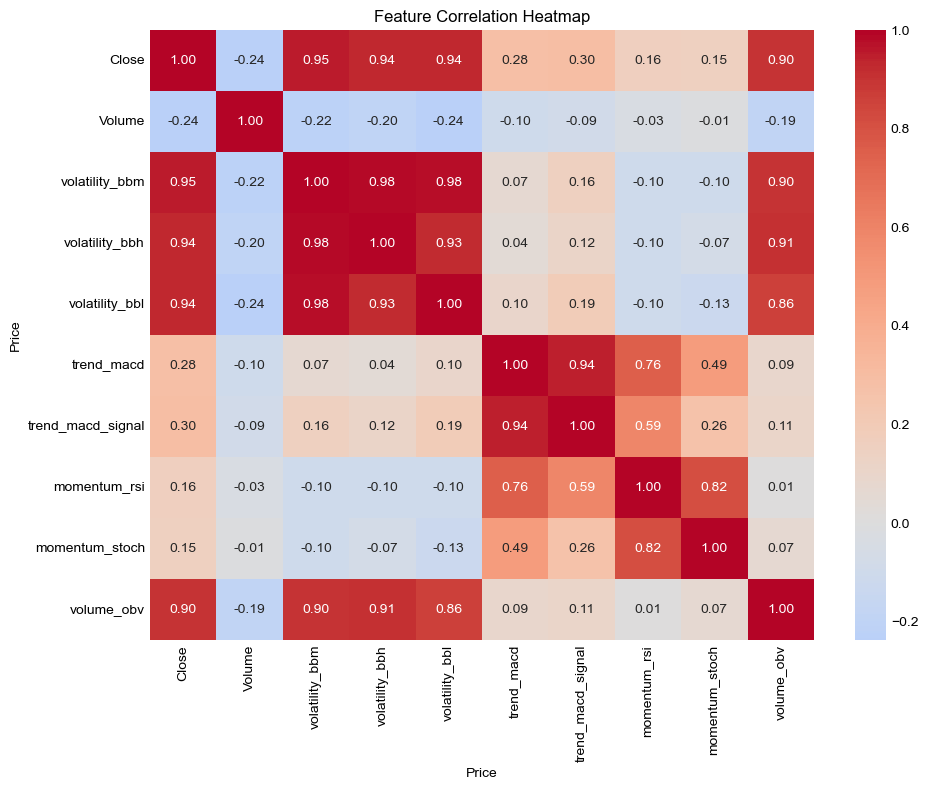

In [15]:

key_features = ['Close', 'Volume', 'volatility_bbm', 'volatility_bbh', 'volatility_bbl',
                'trend_macd', 'trend_macd_signal', 'momentum_rsi', 'momentum_stoch',
                'volume_obv']

available_features = [f for f in key_features if f in df_ta.columns]
corr = df_ta[available_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## RSI plot

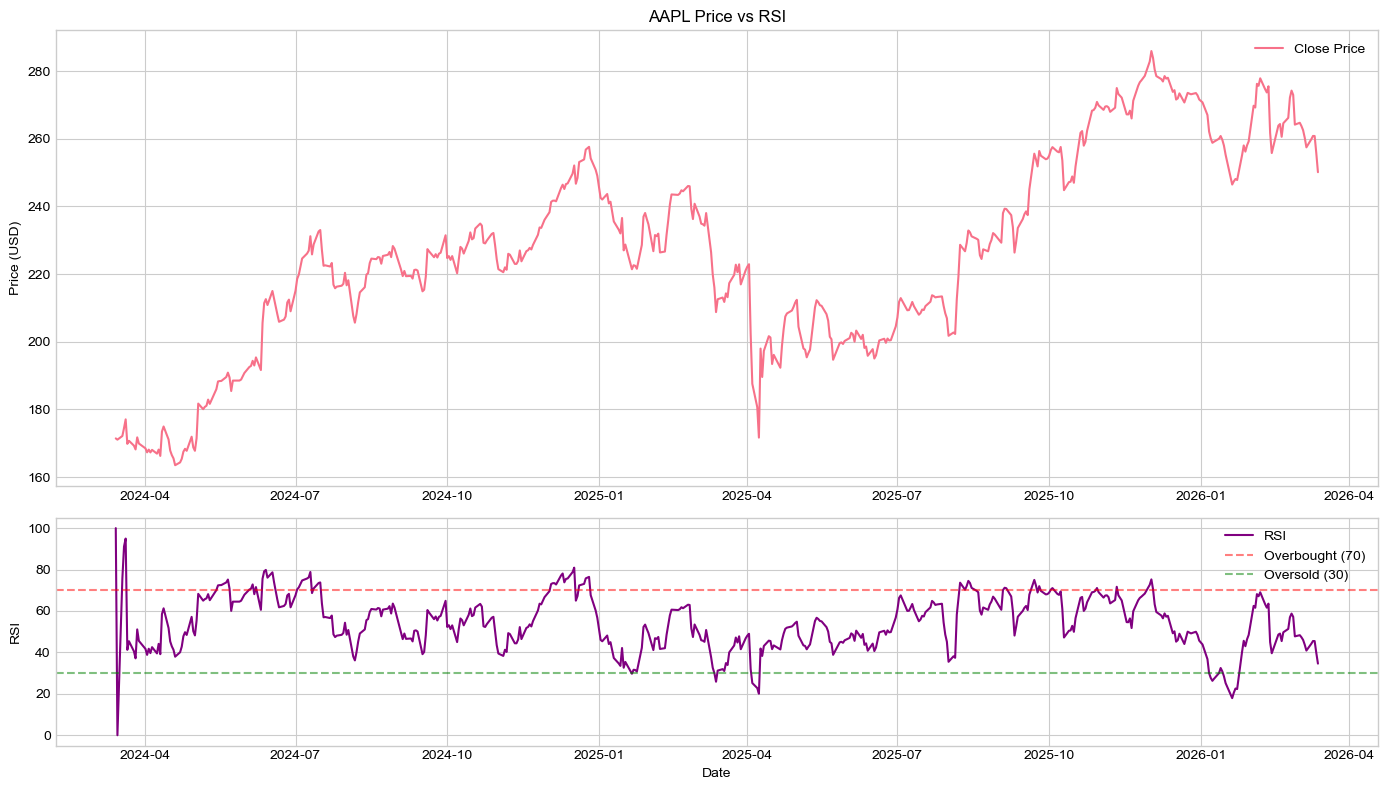

In [16]:

if 'momentum_rsi' in df_ta.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})

    axes[0].plot(df_ta['Close'], label='Close Price')
    axes[0].set_title(f'{ticker} Price vs RSI')
    axes[0].set_ylabel('Price (USD)')
    axes[0].legend()

    axes[1].plot(df_ta['momentum_rsi'], color='purple', label='RSI')
    axes[1].axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
    axes[1].axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
    axes[1].set_ylabel('RSI')
    axes[1].set_xlabel('Date')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## MACD plot

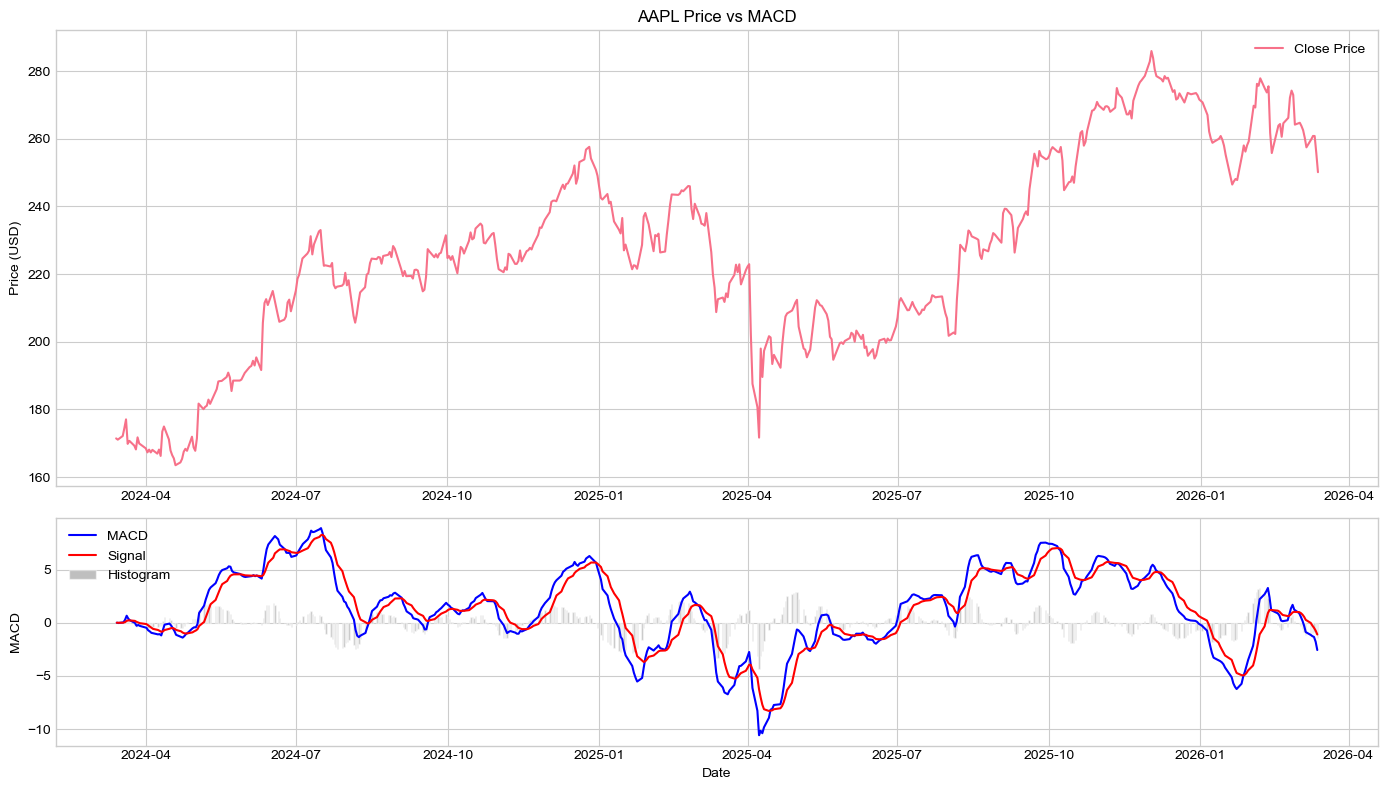

In [17]:

if 'trend_macd' in df_ta.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})

    axes[0].plot(df_ta['Close'], label='Close Price')
    axes[0].set_title(f'{ticker} Price vs MACD')
    axes[0].set_ylabel('Price (USD)')
    axes[0].legend()

    axes[1].plot(df_ta['trend_macd'], label='MACD', color='blue')
    axes[1].plot(df_ta['trend_macd_signal'], label='Signal', color='red')
    axes[1].bar(df_ta.index, df_ta['trend_macd_diff'], label='Histogram', color='gray', alpha=0.5)
    axes[1].set_ylabel('MACD')
    axes[1].set_xlabel('Date')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## Summary

In [18]:

print("=" * 50)
print(f"EXPLORATION SUMMARY - {ticker}")
print("=" * 50)
print(f"Data points: {len(df)}")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Price range: ${df['Close'].min():.2f} - ${df['Close'].max():.2f}")
print(f"Avg daily return: {df['Daily_Return'].mean():.4f}")
print(f"Return std dev: {df['Daily_Return'].std():.4f}")
print(f"Technical indicators available: {df_ta.shape[1]}")
print("=" * 50)
print("\nNext: 02_data_cleaning.ipynb")

EXPLORATION SUMMARY - AAPL
Data points: 501
Date range: 2024-03-14 to 2026-03-13
Price range: $163.51 - $285.92
Avg daily return: 0.0009
Return std dev: 0.0180
Technical indicators available: 91

Next: 02_data_cleaning.ipynb
